# HomeWork 1 - diabetes-health-indicators

## Importações de bibliotecas

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os
from scipy import stats

## Baixando Dataset

In [ ]:
# Download latest version
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("Path to dataset files:", path)
os.listdir(path)

100%|██████████| 6.03M/6.03M [00:00<00:00, 7.86MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/alexteboul/diabetes-health-indicators-dataset/versions/1


['diabetes_binary_health_indicators_BRFSS2015.csv',
 'diabetes_binary_5050split_health_indicators_BRFSS2015.csv',
 'diabetes_012_health_indicators_BRFSS2015.csv']

## PRIMEIRA OLHADA NO DATASET

In [ ]:
df = pd.read_csv(f'{path}/diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
#ramdomizando para ficarmos com as 6000 primeiras com media 0.5
df_random = df.sample(frac=1, random_state=42).reset_index(drop=True)
#pegando as 6000
df_6000 = df_random.iloc[:6000].copy()

In [ ]:
# Primeira analise total
print('Displaying first five rows:')
display(df.head())
print('Displaying last five rows')
display(df.tail())
print(f"Number of rows: {df.shape[0]}\nNumber of columns: {df.shape[1]}")




#delimitando as 6 mil primeiras amostas
print('Displaying last five rows')
display(df_6000.tail())
print(f"Number of rows: {df_6000.shape[0]}\nNumber of columns: {df_6000.shape[1]}")

Displaying first five rows:


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


Displaying last five rows


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
70687,1.0,0.0,1.0,1.0,37.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,0.0,0.0,6.0,4.0,1.0
70688,1.0,0.0,1.0,1.0,29.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,1.0,1.0,10.0,3.0,6.0
70689,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,15.0,0.0,1.0,0.0,13.0,6.0,4.0
70690,1.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
70691,1.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


Number of rows: 70692
Number of columns: 22
Displaying last five rows


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
5995,0.0,1.0,1.0,1.0,35.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,4.0,2.0,30.0,1.0,1.0,8.0,5.0,6.0
5996,1.0,1.0,1.0,1.0,37.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,13.0,4.0,5.0
5997,0.0,0.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,5.0,8.0
5998,0.0,0.0,0.0,1.0,35.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,4.0,6.0,8.0
5999,0.0,1.0,0.0,1.0,22.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,7.0


Number of rows: 6000
Number of columns: 22


### tratando duplicatas

In [ ]:
#tratando dados duplicados -> parece haver poucos
df_6000.duplicated()
df_6000.drop_duplicates(inplace=True)


### se quiser tratar skewness

In [ ]:

# 4. Transformação Yeo-Johnson (Alternativa ao Box-Cox que aceita zeros e valores negativos)
# df_6000['CholCheck'], lmbda = stats.yeojohnson(df_6000['CholCheck'])
# df_6000['BMI'], lmbda = stats.yeojohnson(df_6000['BMI'])
# df_6000['Stroke'], lmbda = stats.yeojohnson(df_6000['Stroke'])
# df_6000['HeartDiseaseorAttack'], lmbda = stats.yeojohnson(df_6000['HeartDiseaseorAttack'])
# df_6000['AnyHealthcare'], lmbda = stats.yeojohnson(df_6000['AnyHealthcare'])
# df_6000['NoDocbcCost'], lmbda = stats.yeojohnson(df_6000['NoDocbcCost'])
# df_6000['PhysHlth'], lmbda = stats.yeojohnson(df_6000['PhysHlth'])
# df_6000['MentHlth'], lmbda = stats.yeojohnson(df_6000['MentHlth'])

## Separando em classes


In [ ]:
#Separando em classes
classes = [df_6000.groupby("Diabetes_binary").get_group(0), df_6000.groupby("Diabetes_binary").get_group(1)]
display(classes[0])
print(f"Number of rows: {classes[0].shape[0]}\nNumber of columns: {classes[0].shape[1]}")
display(classes[1])
print(f"Number of rows: {classes[1].shape[0]}\nNumber of columns: {classes[1].shape[1]}")

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
1,0.0,0.0,0.0,1.0,33.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,3.0,1.0,0.0,13.0,5.0,4.0
2,0.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,5.0,0.0,1.0,8.0,6.0,6.0
3,0.0,0.0,1.0,1.0,29.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,7.0,5.0,8.0
5,0.0,1.0,1.0,1.0,21.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,4.0,30.0,30.0,0.0,0.0,6.0,6.0,4.0
9,0.0,0.0,0.0,1.0,18.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,10.0,6.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5994,0.0,0.0,0.0,1.0,28.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,2.0,0.0,20.0,0.0,0.0,8.0,6.0,8.0
5995,0.0,1.0,1.0,1.0,35.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,4.0,2.0,30.0,1.0,1.0,8.0,5.0,6.0
5997,0.0,0.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,5.0,8.0
5998,0.0,0.0,0.0,1.0,35.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,4.0,6.0,8.0


Number of rows: 3027
Number of columns: 22


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.0,0.0,1.0,1.0,23.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,4.0,0.0,0.0,0.0,0.0,10.0,4.0,5.0
4,1.0,1.0,0.0,1.0,47.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,4.0,30.0,10.0,1.0,1.0,6.0,6.0,3.0
6,1.0,1.0,0.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,4.0,2.0
7,1.0,1.0,1.0,1.0,33.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,4.0,5.0,15.0,1.0,0.0,13.0,4.0,5.0
8,1.0,1.0,1.0,1.0,35.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,4.0,3.0,6.0,1.0,0.0,10.0,4.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5985,1.0,1.0,1.0,1.0,27.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,13.0,5.0,4.0
5988,1.0,1.0,1.0,1.0,34.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,12.0,4.0,5.0
5989,1.0,1.0,1.0,1.0,35.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,4.0,0.0,27.0,1.0,1.0,9.0,6.0,7.0
5990,1.0,0.0,0.0,1.0,30.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,6.0


Number of rows: 2956
Number of columns: 22


## medidas de centro -> Media, desvio padrão, mediana e skewness


In [ ]:
#descrevendo as colunas de nosso dataset
print('\nDescrição dos dados:\n')
display(df_6000.describe(include = 'all'))

#calculando o skewness
display(df_6000.skew(numeric_only=True))

#descreve os dados nulos
print('\nDescrição das colunas nulas\n')
display(df_6000.info())




Descrição dos dados:



,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,...,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000,5983.000000
mean,0.494067,0.559753,0.530503,0.976433,29.632626,0.474344,0.063848,0.143908,0.708173,0.605048,...,0.955039,0.092596,2.836203,3.743607,5.929801,0.254053,0.446432,8.601203,4.911583,5.705666
std,0.500007,0.496458,0.499110,0.151708,7.036925,0.499383,0.244502,0.351025,0.454641,0.488881,...,0.207235,0.289889,1.120870,8.160631,10.146787,0.435364,0.497164,2.863858,1.009502,2.159499
min,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.000000,1.000000,1.000000,1.000000,28.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


,0
Diabetes_binary,0.023742
HighBP,-0.240796
HighChol,-0.122271
CholCheck,-6.283037
BMI,1.688465
Smoker,0.102785
Stroke,3.568878
HeartDiseaseorAttack,2.029547
PhysActivity,-0.916076
Fruits,-0.429891



Descrição das colunas nulas

<class 'pandas.core.frame.DataFrame'>
Index: 5983 entries, 0 to 5999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       5983 non-null   float64
 1   HighBP                5983 non-null   float64
 2   HighChol              5983 non-null   float64
 3   CholCheck             5983 non-null   float64
 4   BMI                   5983 non-null   float64
 5   Smoker                5983 non-null   float64
 6   Stroke                5983 non-null   float64
 7   HeartDiseaseorAttack  5983 non-null   float64
 8   PhysActivity          5983 non-null   float64
 9   Fruits                5983 non-null   float64
 10  Veggies               5983 non-null   float64
 11  HvyAlcoholConsump     5983 non-null   float64
 12  AnyHealthcare         5983 non-null   float64
 13  NoDocbcCost           5983 non-null   float64
 14  GenHlth               5983 non-null   float64
 

None

In [ ]:
#descrevendo as colunas de nossa data
print('\ndescrição dos dados:\n')
display(classes[0].describe(include = 'all'))
display(classes[1].describe(include = 'all'))
#calculando o skewness
print("diabets binary 0")
display(classes[0].skew(numeric_only=True))
print("diabets binary 1")
display(classes[1].skew(numeric_only=True))




descrição dos dados:



,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,3027.0,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000,...,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000,3027.000000
mean,0.0,0.371985,0.381566,0.960687,27.515031,0.435084,0.029402,0.071688,0.779980,0.629336,...,0.949455,0.084242,2.391477,2.929964,3.740667,0.141064,0.417245,7.828873,5.090188,6.204823
std,0.0,0.483414,0.485851,0.194370,6.147936,0.495850,0.168959,0.258013,0.414328,0.483062,...,0.219103,0.277796,1.043201,7.028014,8.211300,0.348145,0.493185,3.120798,0.946413,1.976649
min,0.0,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.0,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.0,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.0,1.000000,1.000000,1.000000,30.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,2.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,0.0,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,2956.0,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,...,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.00000
mean,1.0,0.752030,0.683018,0.992558,31.801083,0.514547,0.099120,0.217862,0.634641,0.580176,...,0.960758,0.101150,3.291610,4.576793,8.171516,0.369756,0.476319,9.392084,4.728687,5.19452
std,0.0,0.431908,0.465379,0.085963,7.227767,0.499873,0.298874,0.412863,0.481612,0.493613,...,0.194204,0.301579,1.009369,9.102863,11.377242,0.482820,0.499523,2.322302,1.039069,2.21876
min,1.0,0.000000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000
25%,1.0,1.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,4.000000,3.00000
50%,1.0,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,2.000000,0.000000,0.000000,10.000000,5.000000,5.00000
75%,1.0,1.000000,1.000000,1.000000,35.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,3.000000,15.000000,1.000000,1.000000,11.000000,6.000000,7.00000
max,1.0,1.000000,1.000000,1.000000,84.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.00000


diabets binary 0


,0
Diabetes_binary,0.000000
HighBP,0.529977
HighChol,0.487855
CholCheck,-4.743437
BMI,2.543599
Smoker,0.262009
Stroke,5.574255
HeartDiseaseorAttack,3.322269
PhysActivity,-1.352384
Fruits,-0.535838


diabets binary 1


,0
Diabetes_binary,0.000000
HighBP,-1.167844
HighChol,-0.787063
CholCheck,-11.467545
BMI,1.302187
Smoker,-0.058241
Stroke,2.684414
HeartDiseaseorAttack,1.367665
PhysActivity,-0.559507
Fruits,-0.325073


## ANALISE UNIVARIADA


### Binarios

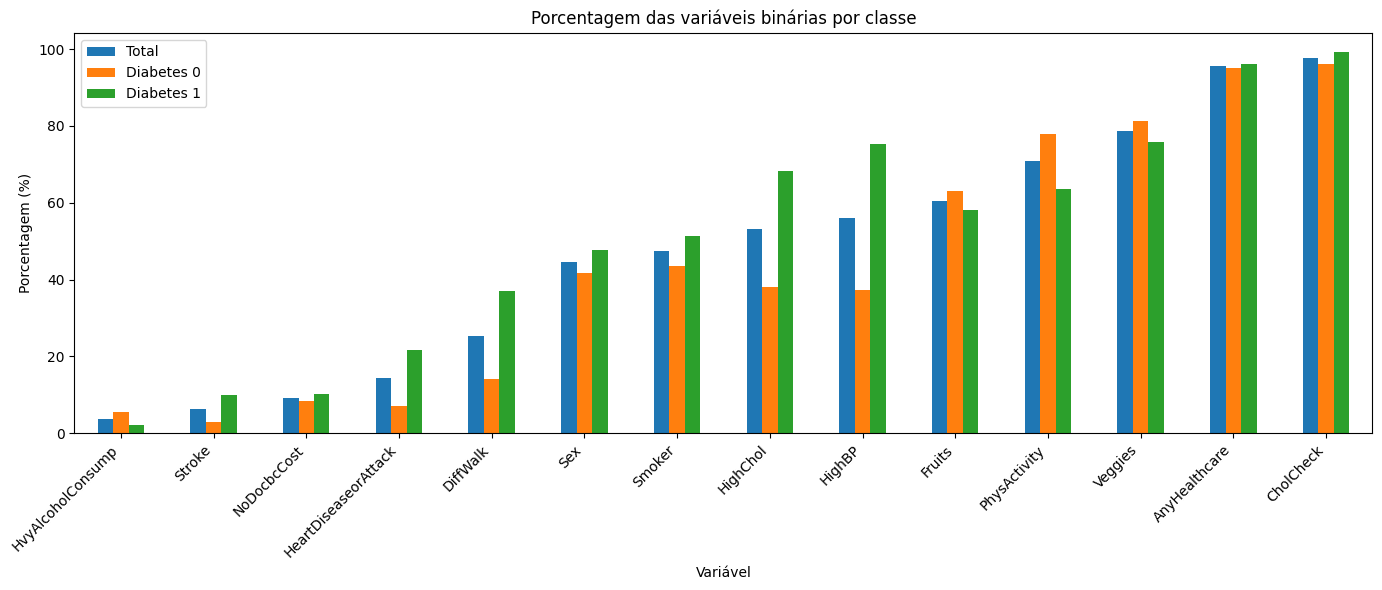

In [ ]:
#plots variaveis binárias
binarias = [
    "HighBP", "HighChol", "CholCheck", "Smoker",
    "Stroke", "HeartDiseaseorAttack", "PhysActivity",
    "Fruits", "Veggies", "HvyAlcoholConsump",
    "AnyHealthcare", "NoDocbcCost", "DiffWalk", "Sex"
]

perc = pd.DataFrame({
    "Total": df_6000[binarias].mean() * 100,
    "Diabetes 0": classes[0][binarias].mean() * 100,
    "Diabetes 1": classes[1][binarias].mean() * 100
})

perc = perc.sort_values("Total")

perc.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.ylabel("Porcentagem (%)")
plt.xlabel("Variável")
plt.title("Porcentagem das variáveis binárias por classe")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### categóricos

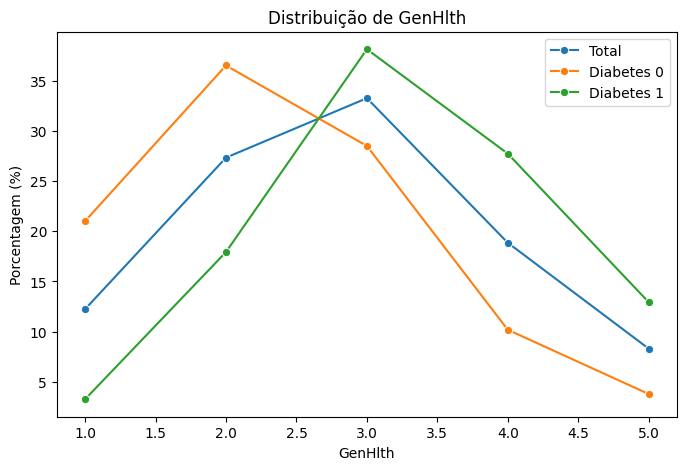

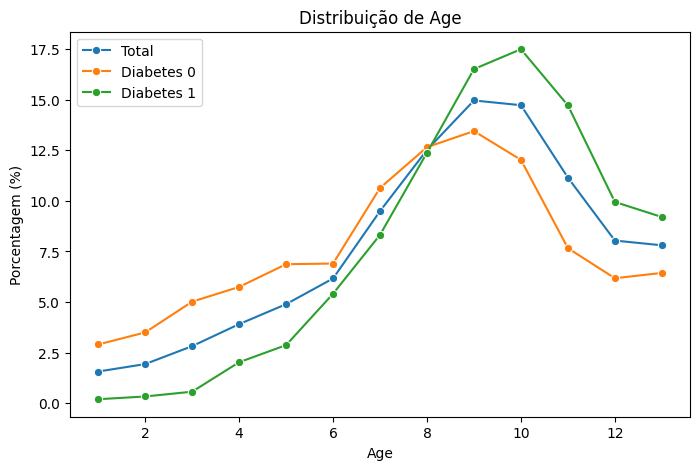

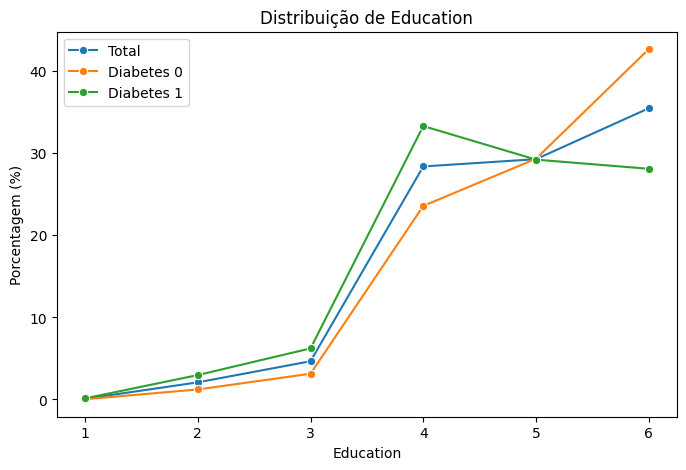

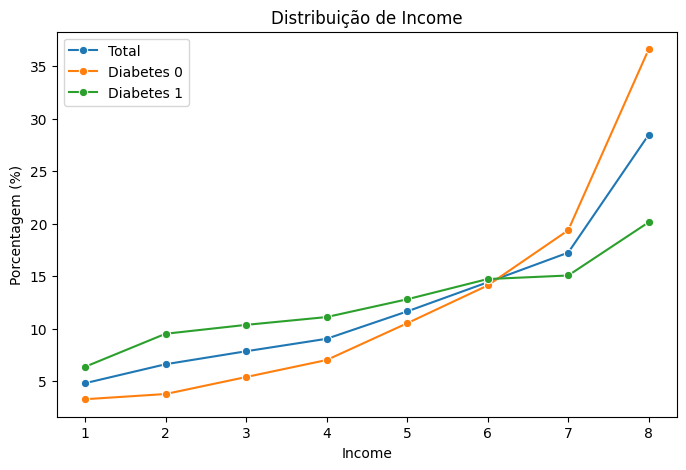

In [ ]:
#dados categoricos
categoricas = ["GenHlth", "Age", "Education", "Income"]

for variavel in categoricas:

    total = df_6000[variavel].value_counts(normalize=True).sort_index() * 100
    classe0 = classes[0][variavel].value_counts(normalize=True).sort_index() * 100
    classe1 = classes[1][variavel].value_counts(normalize=True).sort_index() * 100

    plot_df = pd.DataFrame({
        "Total": total,
        "Diabetes 0": classe0,
        "Diabetes 1": classe1
    }).reset_index()

    plot_df = plot_df.rename(columns={"index": variavel})

    plt.figure(figsize=(8, 5))

    sns.lineplot(
        data=plot_df,
        x=variavel,
        y="Total",
        marker="o",
        label="Total"
    )

    sns.lineplot(
        data=plot_df,
        x=variavel,
        y="Diabetes 0",
        marker="o",
        label="Diabetes 0"
    )

    sns.lineplot(
        data=plot_df,
        x=variavel,
        y="Diabetes 1",
        marker="o",
        label="Diabetes 1"
    )

    plt.ylabel("Porcentagem (%)")
    plt.title(f"Distribuição de {variavel}")
    plt.show()

### Quantitativos


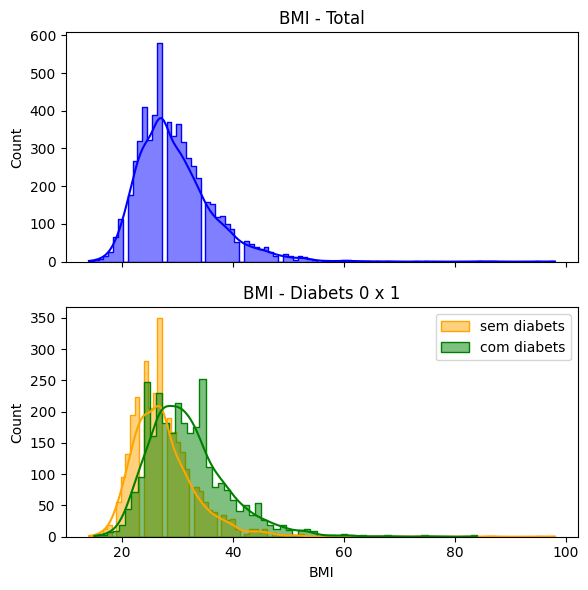

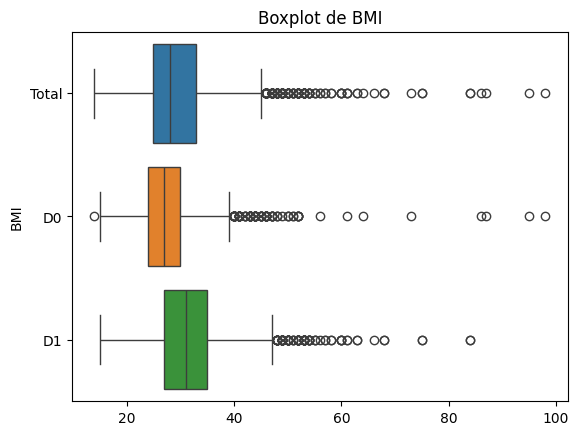

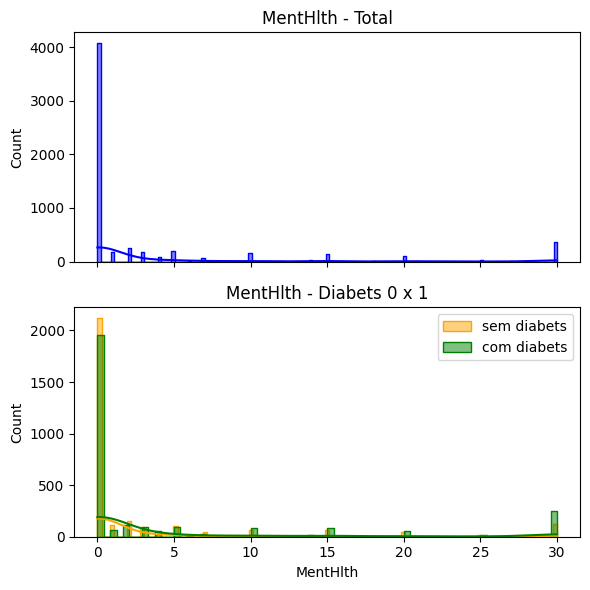

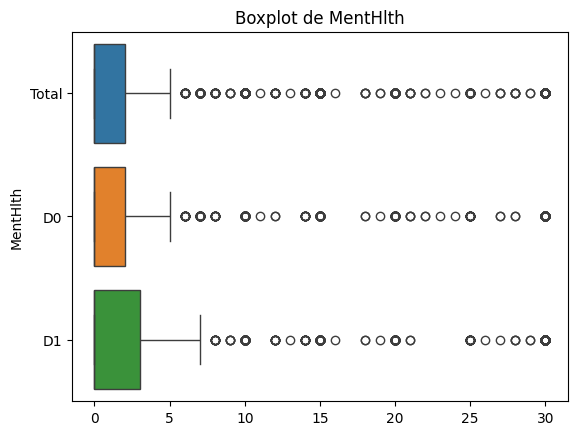

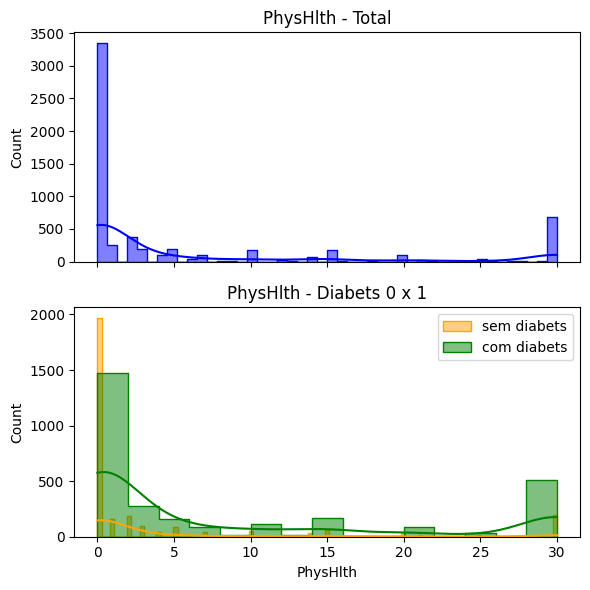

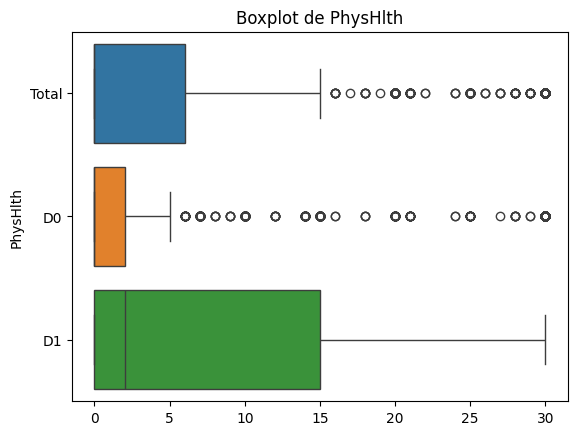

In [ ]:
#variaveis quantitativas
categoria = ["BMI", 'MentHlth', 'PhysHlth']

for variavel in categoria:
  fig, axes = plt.subplots(2, 1, figsize=(6, 6), sharex=True)
  datas = pd.DataFrame({
      "Total": df_6000[variavel],
      "D0": classes[0][variavel],
      "D1": classes[1][variavel]
  })


  sns.histplot(datas["Total"],
      element="step",
      kde=True,
      label="Total",
      color='blue',
      ax = axes[0])
  axes[0].set_title( f"{variavel} - Total")

  sns.histplot(datas["D0"],
      element="step",
      kde=True,
      color='orange',
      label="sem diabets",
      ax = axes[1])
  axes[1].set_title(f"{variavel} - Diabets 0 x 1")

  sns.histplot(datas["D1"],
      element="step",
      kde=True,
      color='green',
      label="com diabets",
      ax = axes[1])
  plt.tight_layout()
  plt.xlabel(variavel)
  plt.legend()
  plt.show()

  sns.boxplot(data=datas, orient="h")

  plt.ylabel(variavel)
  plt.title(f"Boxplot de {variavel}")
  plt.show()

# sns.scatterplot(data=df_6000, x='BMI', y='Income')
# plt.title('BMI x renda')
# plt.show()

### Geral

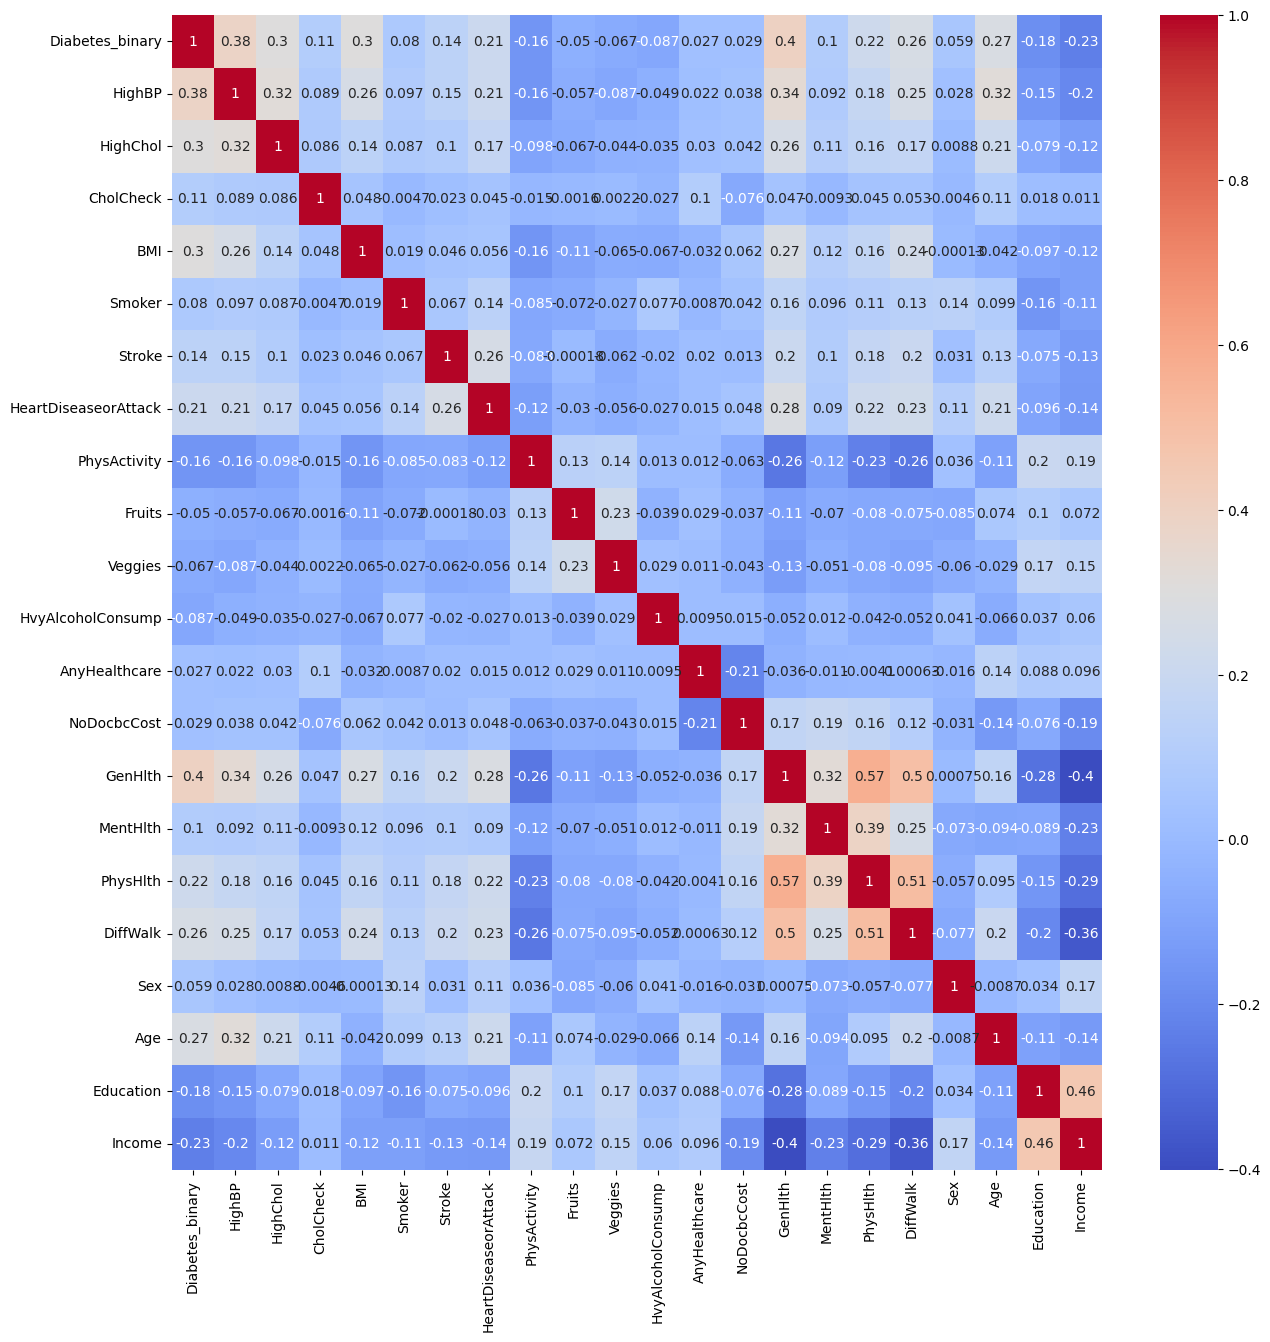

In [ ]:
#analizando a matriz de correlação por um mapa de calor
plt.figure(figsize = (15,15))
sns.heatmap(df_6000.select_dtypes(['float64' , 'int64']).corr(),annot=True, cmap="coolwarm")
plt.show()


## ANALISE BIVARIADA

### BINÁRIAS


In [ ]:
binarias = [
    "HighBP",
    "HighChol",
    "CholCheck",
    "Smoker",
    "Stroke",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "Veggies",
    "HvyAlcoholConsump",
    "AnyHealthcare",
    "NoDocbcCost",
    "DiffWalk",
    "Sex",
    "Diabetes_binary"
]

matriz_phi = df_6000[binarias].corr(method="pearson")

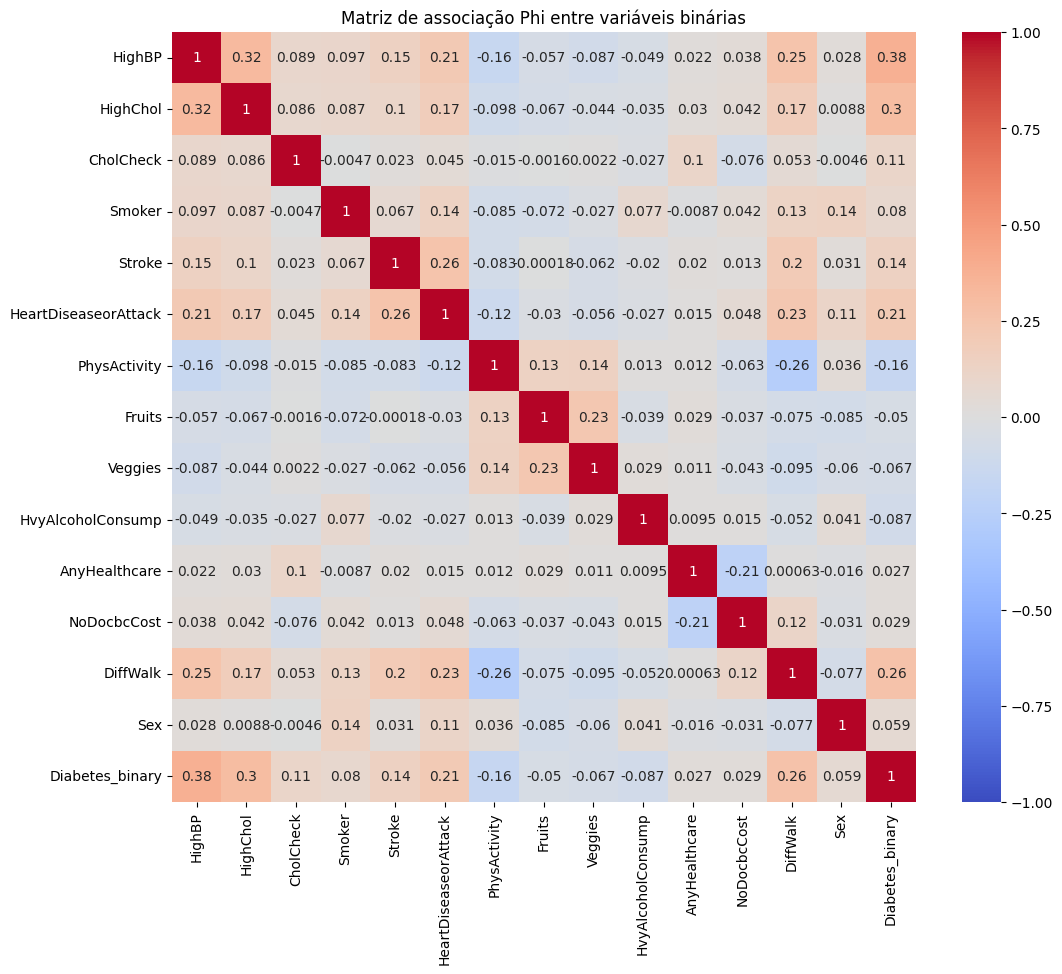

In [ ]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz_phi,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Matriz de associação Phi entre variáveis binárias")
plt.show()

### QUALITATIVA x QUALITATIVA

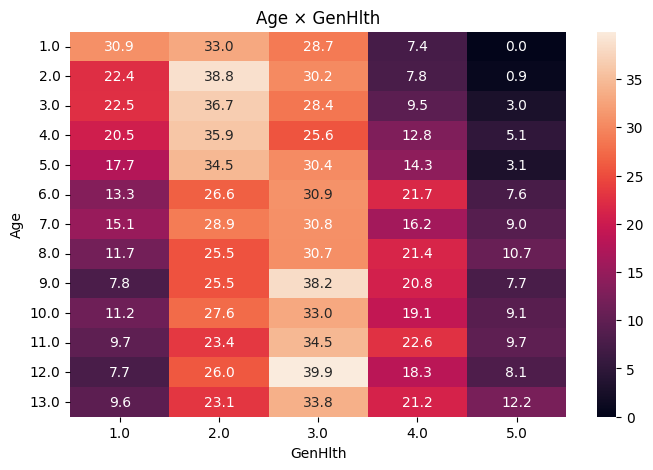

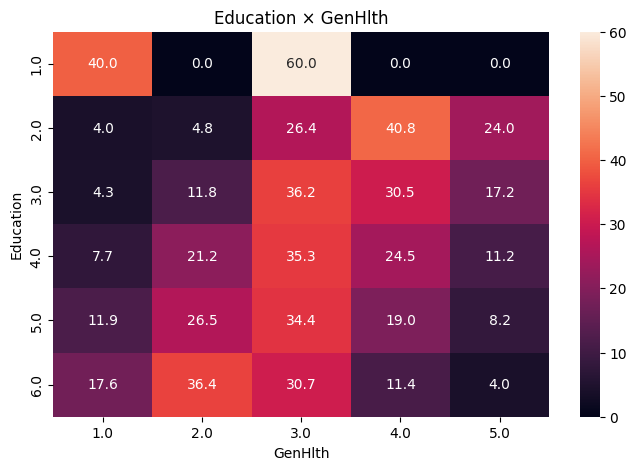

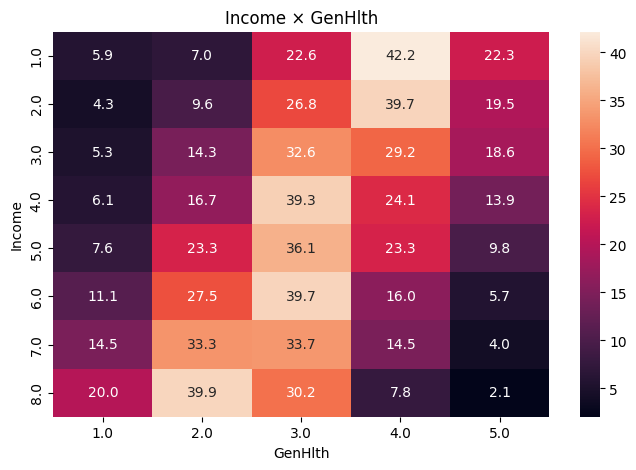

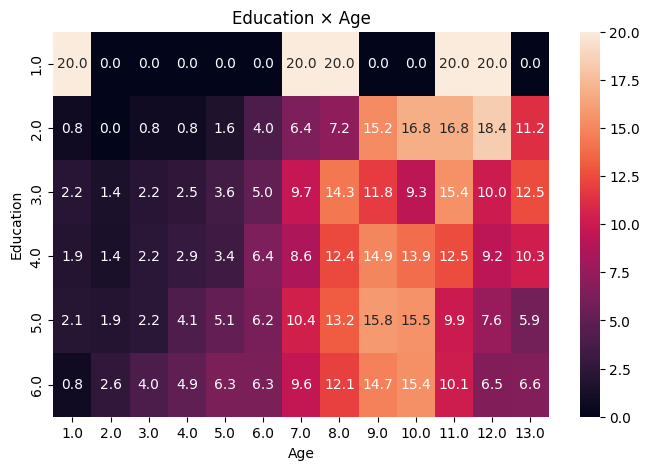

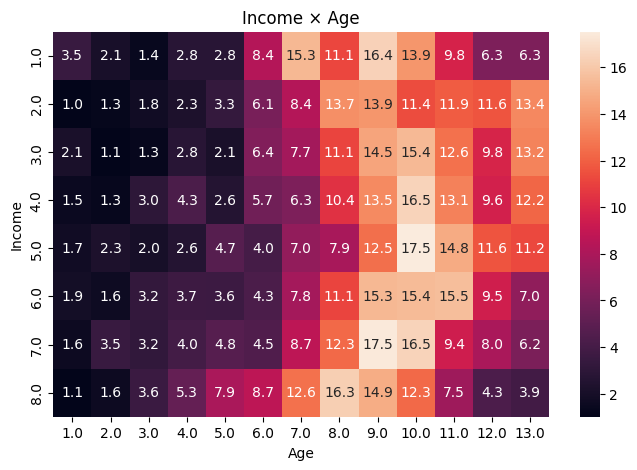

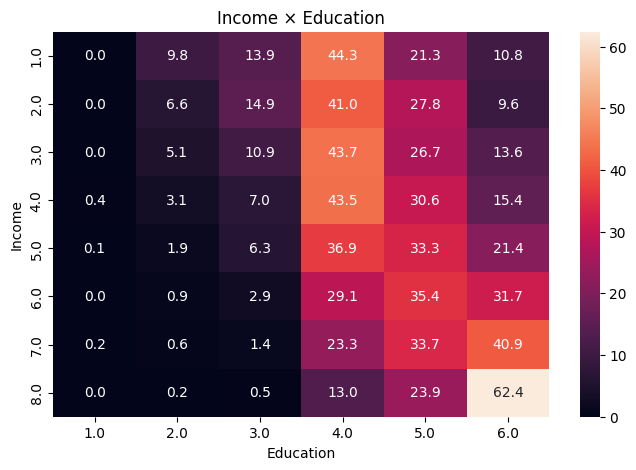

In [ ]:
ordinais = ["GenHlth", "Age", "Education", "Income"]

for i in range(len(ordinais)):
    for j in range(i + 1, len(ordinais)):

        x = ordinais[i]
        y = ordinais[j]

        tabela = pd.crosstab(
            df_6000[y],
            df_6000[x],
            normalize="index"
        ) * 100

        plt.figure(figsize=(8, 5))

        sns.heatmap(
            tabela,
            annot=True,
            fmt=".1f"
        )

        plt.title(f"{y} × {x}")
        plt.xlabel(x)
        plt.ylabel(y)

        plt.show()

### QUANTITATIVA x QUANTITATIVA

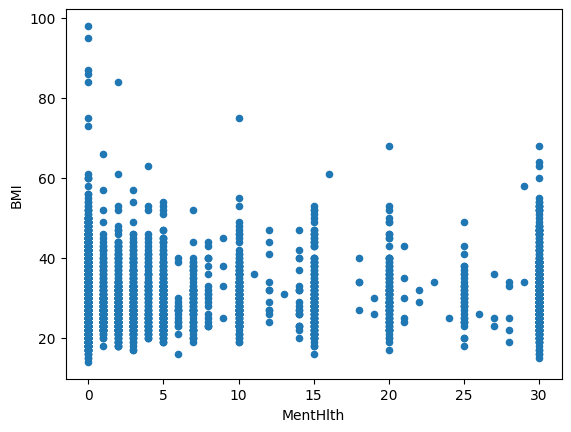

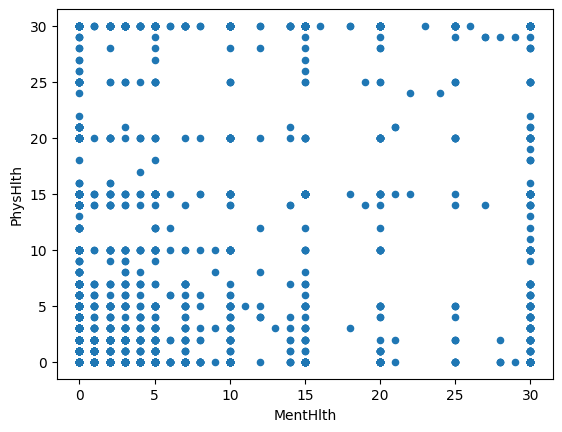

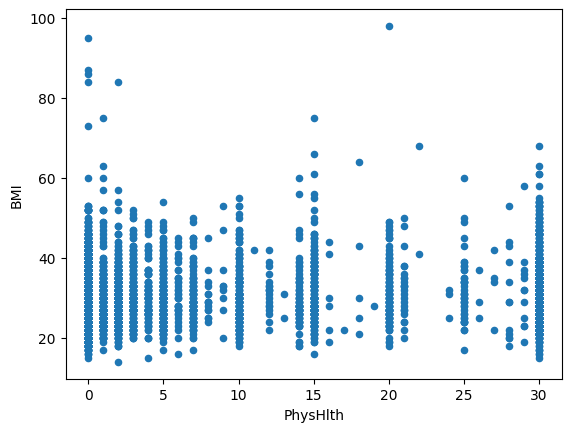

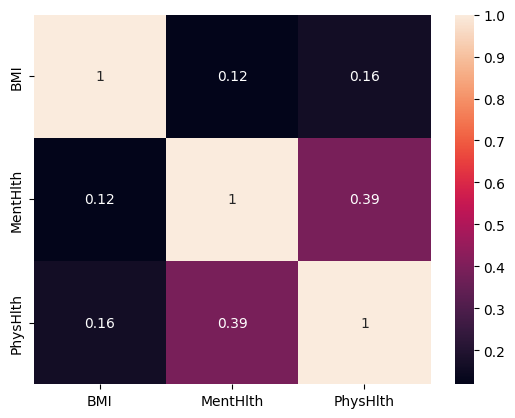

In [ ]:
#variaveis quantitativas x quantitativas
categoria = ["BMI", 'MentHlth', 'PhysHlth']
df_6000.plot(x=categoria[1],y=categoria[0],kind = 'scatter')
plt.show()
df_6000.plot(x=categoria[1],y=categoria[2],kind = 'scatter')
plt.show()
df_6000.plot(x=categoria[2],y=categoria[0],kind = 'scatter')
plt.show()

quantitativos = df_6000[categoria]
quantitativos.select_dtypes(['float64' , 'float64']).corr()
sns.heatmap(quantitativos.select_dtypes(['float64' , 'int64']).corr(),annot=True)
plt.show()




### QUANTITATIVA X QUALITATIVA

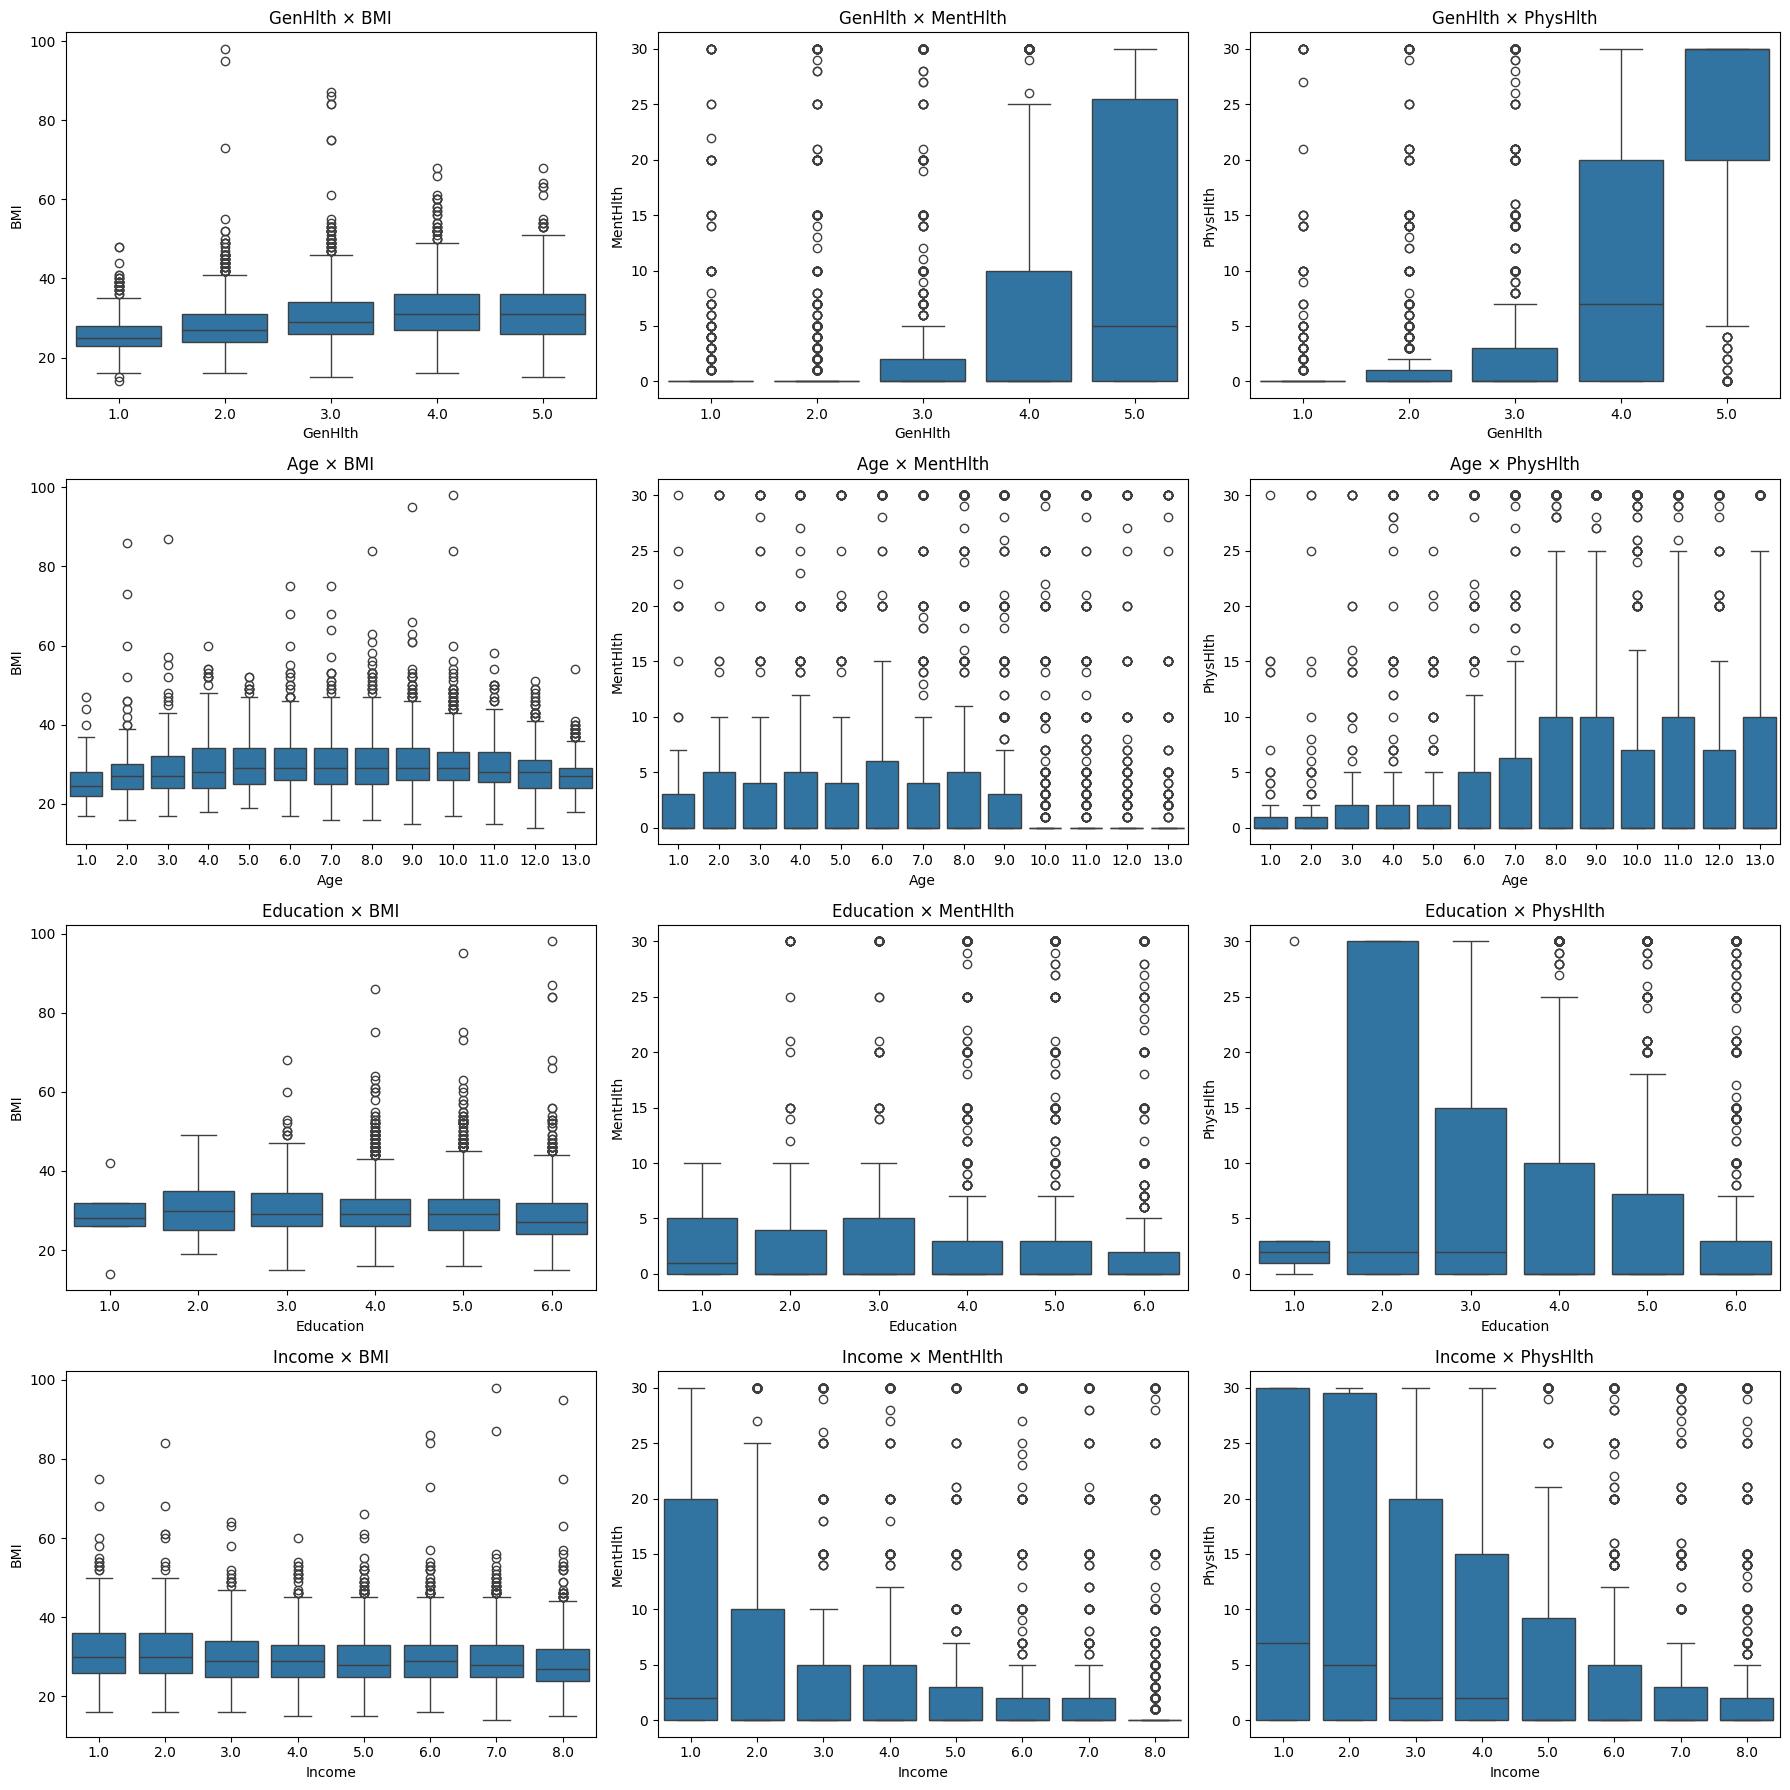

In [ ]:
# GenHlth - nível de saúde - qualitativa ordinaria - float64
# Age - nivel de idade de 0 a 13 – qualitativa ordinal -  float64
# Education - nivel de escolaridade - qualitativa ordinal float64
#  Income - nivel de renda - 1 a 8 – qualitativa ordinal float64
qualitativas = ["GenHlth", "Age", "Education", "Income"]
quantitativas = ["BMI", "MentHlth", "PhysHlth"]

fig, axes = plt.subplots(
    len(qualitativas),
    len(quantitativas),
    figsize=(18, 18)
)

for i, x in enumerate(qualitativas):
    for j, y in enumerate(quantitativas):

        sns.boxplot(
            data=df_6000,
            x=x,
            y=y,
            ax=axes[i, j]
        )

        axes[i, j].set_title(f"{x} × {y}")

plt.tight_layout()
plt.show()


## Remoção de Preditores

In [ ]:
def remove_collinear_predictors(
    df,
    columns=None,
    threshold=0.8,
    method="pearson"
):
    """
    Remove variáveis com alta correlação entre si.

    Se 'columns' for informado, utiliza essa lista de colunas.
    Caso contrário, seleciona automaticamente apenas as colunas numéricas.
    """

    # Seleciona as colunas que serão analisadas
    if columns is not None:
        features = list(columns)
    else:
        features = list(
            df.select_dtypes(
                include=[np.number]
            ).columns
        )

    removed_features = []

    while True:

        # Matriz de correlação em valor absoluto
        corr_matrix = df[features].corr(
            method=method
        ).abs()

        # Zera a diagonal principal (autocorrelação)
        np.fill_diagonal(
            corr_matrix.values,
            0.0
        )

        # Maior correlação encontrada
        max_corr = corr_matrix.values.max()

        # Critério de parada
        if max_corr < threshold:
            break

        # Identifica o par de variáveis
        # com maior correlação
        row_idx, col_idx = np.unravel_index(
            corr_matrix.values.argmax(),
            corr_matrix.shape
        )

        var_A = corr_matrix.index[row_idx]
        var_B = corr_matrix.columns[col_idx]

        # Calcula a correlação média de cada variável
        # com as demais variáveis
        avg_corr_A = corr_matrix.loc[var_A].mean()
        avg_corr_B = corr_matrix.loc[var_B].mean()

        # Remove a variável com maior correlação média
        if avg_corr_A >= avg_corr_B:
            to_remove = var_A
        else:
            to_remove = var_B

        features.remove(to_remove)

        removed_features.append(
            (to_remove, float(max_corr))
        )

    return (
        df[features],
        features,
        removed_features
    )

In [ ]:
# Executar a filtragem no DataFrame df_6000

df_filtrado, mantidas, removidas = remove_collinear_predictors(
    df_6000,
    columns=numericos,
    threshold=0.1
)

print("Variáveis mantidas:", mantidas)
print("Variáveis removidas:", removidas)

Variáveis mantidas: ['Smoker', 'Age', 'BMI']
Variáveis removidas: [('GenHlth', 0.5688750068893539), ('Income', 0.4556669806329282), ('PhysHlth', 0.38966244395761207), ('HighBP', 0.318933582646758), ('HighChol', 0.2145801513653423), ('HeartDiseaseorAttack', 0.21440698162340782), ('PhysActivity', 0.1958194824639111), ('Education', 0.15985430838460746), ('MentHlth', 0.11872482261067263), ('Fruits', 0.10506162136578419)]


## Algoritmo Combinatório

In [ ]:
import itertools
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Lista de variáveis preditoras
numericos = [
    "HighBP",
    "HighChol",
    "Smoker",
    "HeartDiseaseorAttack",
    "PhysActivity",
    "Fruits",
    "MentHlth",
    "PhysHlth",
    "Age",
    "BMI",
    "Income",
    "Education",
    "GenHlth"
]


def encontrar_melhores_combinacoes_pca(
    df,
    variaveis,
    min_vars=4,
    top_n=10
):
    """
    Testa todas as combinações possíveis de variáveis,
    a partir de min_vars, e calcula a variância explicada
    por PC1 + PC2 para cada combinação.
    """

    resultados = []

    # 1. Padronizar todas as variáveis preditoras
    # utilizando Z-score
    scaler = StandardScaler()

    X_scaled = pd.DataFrame(
        scaler.fit_transform(df[variaveis]),
        columns=variaveis
    )

    total_vars = len(variaveis)

    # 2. Iterar por todos os tamanhos de grupo,
    # desde min_vars até o total de variáveis
    for k in range(min_vars, total_vars + 1):

        # Gerar todas as combinações de tamanho k
        for comb in itertools.combinations(
            variaveis,
            k
        ):

            subconjunto = list(comb)

            # Selecionar as variáveis da combinação
            X_sub = X_scaled[subconjunto]

            # Ajustar o PCA com 2 componentes
            pca = PCA(
                n_components=2
            )

            pca.fit(X_sub)

            # Calcular a soma da variância explicada
            # por PC1 e PC2
            var_explicada_2pc = (
                np.sum(
                    pca.explained_variance_ratio_
                ) * 100
            )

            # Armazenar os resultados
            resultados.append({
                "qtd_variaveis": k,
                "var_explicada_PC1_PC2 (%)": round(
                    var_explicada_2pc,
                    2
                ),
                "combinacao": subconjunto
            })

    # 3. Converter os resultados para DataFrame
    df_resultados = pd.DataFrame(
        resultados
    )

    # Ordenar da maior para a menor
    # variância explicada
    df_resultados = df_resultados.sort_values(
        by="var_explicada_PC1_PC2 (%)",
        ascending=False
    ).reset_index(drop=True)

    print(
        f"Total de combinações testadas: "
        f"{len(df_resultados)}"
    )

    print(
        f"\n--- Top {top_n} Melhores Combinações ---"
    )

    print(
        df_resultados.head(top_n)
    )

    return df_resultados


# Executar no DataFrame df_6000
df_ranking_pca = encontrar_melhores_combinacoes_pca(
    df_6000,
    numericos,
    min_vars=7,
    top_n=15
)

Total de combinações testadas: 4096

--- Top 15 Melhores Combinações ---
    qtd_variaveis  var_explicada_PC1_PC2 (%)  \
0               7                      54.20   
1               7                      53.72   
2               7                      53.70   
3               7                      53.33   
4               7                      52.96   
5               7                      52.77   
6               7                      52.56   
7               7                      52.54   
8               7                      52.46   
9               7                      52.46   
10              7                      52.44   
11              7                      52.34   
12              7                      52.32   
13              7                      52.30   
14              7                      52.26   

                                           combinacao  
0   [HighBP, HighChol, MentHlth, PhysHlth, Age, In...  
1   [HighBP, MentHlth, PhysHlth, Age, Income, 

## Análise Multivariada

### Preditores escolhidos

In [ ]:
numericos = [
    "HighBP",
    "HighChol",
    "MentHlth",
    "PhysHlth",
    "Age",
    "GenHlth"
]

### Construção do PCA

In [ ]:
# Construção do PCA
# Passo 1: Obter Matriz de Covariância ou Correlação

from sklearn.preprocessing import StandardScaler

# Matriz de correlação
Mcorrelacao = df_6000[numericos].corr(method="pearson")


# Passo 2: Decomposição em Autovalores e Autovetores
autovalores, autovetores = np.linalg.eig(Mcorrelacao)


# Passo 3: Ordenar os autovalores em ordem decrescente
indices = np.argsort(autovalores)[::-1]

autovalores_decres = autovalores[indices]
autovetores_decres = autovetores[indices]


# Passo 4: Cálculo da variância explicada e acumulada
variancia_explicada = (
    autovalores_decres / np.sum(autovalores_decres)
) * 100

variancia_acumulada = np.cumsum(
    variancia_explicada
)


# Passo 5: Tabela de variância explicada e acumulada
df_PC = pd.DataFrame({
    "Componente": [
        f"PC{i+1}"
        for i in range(len(autovalores_decres))
    ],
    "Autovalor": autovalores_decres,
    "Var. Explicada (%)": variancia_explicada,
    "Var. Acumulada (%)": variancia_acumulada
})

print("--- Tabela de Variância Explicada ---")
print(df_PC.round(2))



--- Tabela de Variância Explicada ---
  Componente  Autovalor  Var. Explicada (%)  Var. Acumulada (%)
0        PC1       2.22               37.04               37.04
1        PC2       1.32               21.99               59.03
2        PC3       0.79               13.19               72.22
3        PC4       0.65               10.75               82.97
4        PC5       0.62               10.34               93.31
5        PC6       0.40                6.69              100.00


### Biplot do PCA 1 e 2

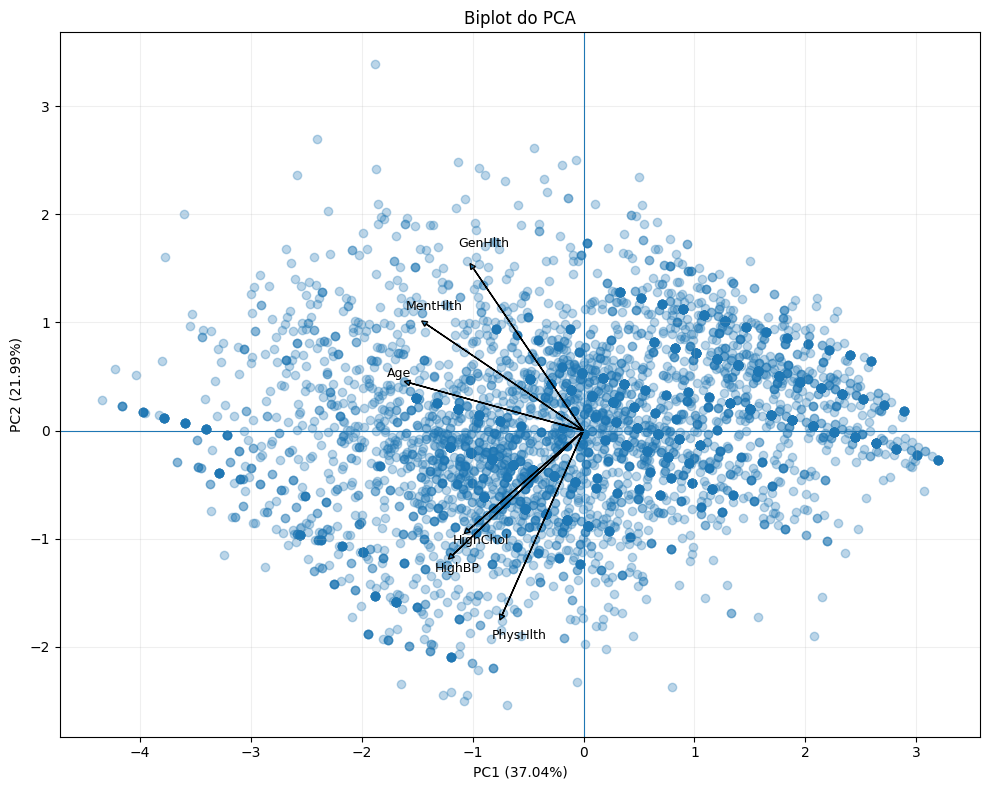

In [ ]:
# Biplot do PCA

# Padronização dos dados
scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    df_6000[numericos]
)


# Número de componentes utilizados
M = len(autovalores_decres)


# Matriz dos componentes
W = autovetores_decres[:, :M]


# Projeção dos dados no espaço dos componentes
X_pca = np.dot(
    X_scaled,
    W
)


plt.figure(figsize=(10, 8))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.3
)

escala = 3

for i, variavel in enumerate(numericos):

    plt.arrow(
        0, 0,
        W[i, 0] * escala,
        W[i, 1] * escala,
        head_width=0.05,
        head_length=0.05,
        length_includes_head=True
    )

    plt.text(
        W[i, 0] * escala * 1.1,
        W[i, 1] * escala * 1.1,
        variavel,
        fontsize=9
    )

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(f"PC1 ({variancia_explicada[0]:.2f}%)")
plt.ylabel(f"PC2 ({variancia_explicada[1]:.2f}%)")

plt.title("Biplot do PCA")

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### Gráfico mapa de calor dos PCA's

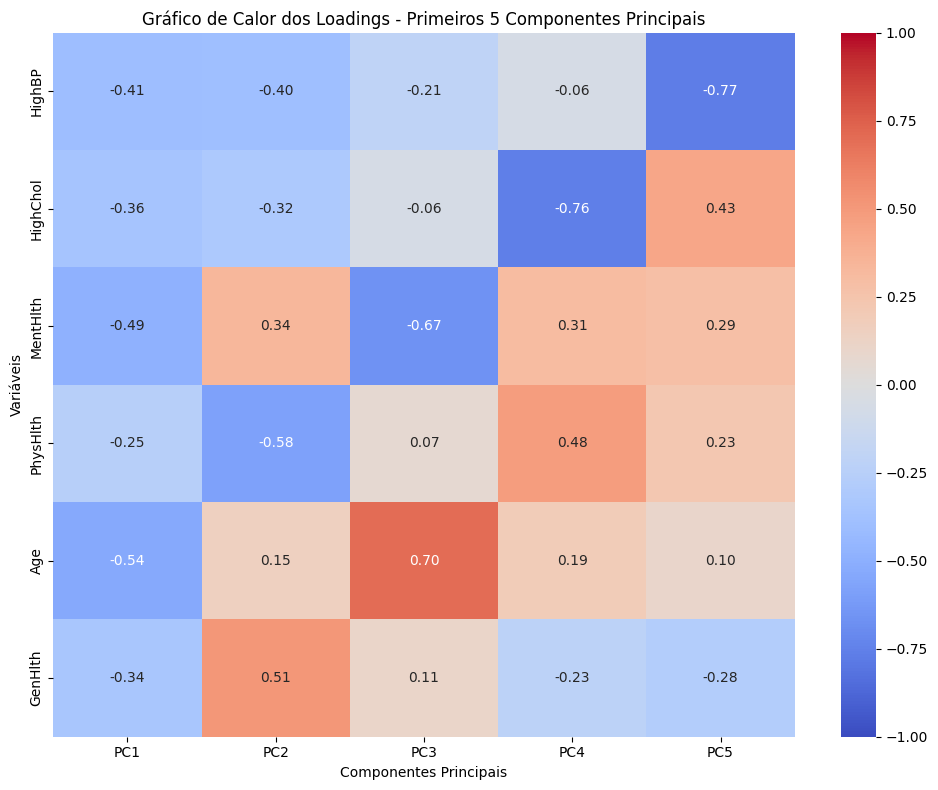

In [ ]:
qtd_pcs = 5


# Garantir que a quantidade escolhida não ultrapasse
# o número de componentes disponíveis
qtd_pcs = min(qtd_pcs, autovetores_decres.shape[1])


# ============================================================
# Matriz de loadings
# ============================================================

loadings = autovetores_decres[:, :qtd_pcs]


# ============================================================
# Criar nomes dos componentes
# ============================================================

nomes_pcs = [
    f"PC{i+1}"
    for i in range(qtd_pcs)
]


# ============================================================
# Criar DataFrame para o heatmap
# ============================================================

df_loadings = pd.DataFrame(
    loadings,
    index=numericos,
    columns=nomes_pcs
)


# ============================================================
# Gráfico de calor
# ============================================================

plt.figure(figsize=(10, 8))

sns.heatmap(
    df_loadings,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title(
    f"Gráfico de Calor dos Loadings - "
    f"Primeiros {qtd_pcs} Componentes Principais"
)

plt.xlabel("Componentes Principais")
plt.ylabel("Variáveis")

plt.tight_layout()
plt.show()